In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed_data.csv")

print("Processed dataset loaded!")
print("Shape:", df.shape)

Processed dataset loaded!
Shape: (10000, 14)


In [3]:
print(df.columns.tolist())

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_H', 'Type_L', 'Type_M', 'Machine failure']


In [4]:
X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 13)
y shape: (10000,)


In [5]:
X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 13)
Testing data: (2000, 13)


In [6]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.999
Accuracy (%): 99.9


In [9]:
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 1.0
Recall: 0.9705882352941176
F1-score: 0.9850746268656716


In [10]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1932    0]
 [   2   66]]


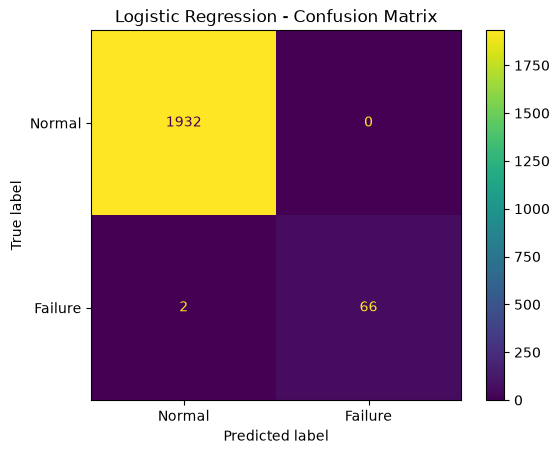

In [12]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Failure"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [13]:
import joblib

joblib.dump(model, "../models/logistic_regression_model.pkl")

print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!
